# Linear Regression — Predicting EstimatedSalary, Balance, and CreditScore

Before jumping into classification (predicting churn), this notebook explores whether
any of the three main financial/numeric columns can be predicted from the others using
**Linear Regression** — a model that assumes a straight-line relationship between
inputs and the target.

This isn't just a warm-up exercise: the results below reveal something important about
the dataset itself, which will explain why the next notebook uses a different kind of
model entirely.

In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

## 2. Load the Cleaned, Outlier-Checked Dataset

This is the final dataset from the previous two notebooks — fully cleaned, reconciled
against the reference file, and checked for outliers. Starting modeling from here means
we're not re-doing any cleaning work, just building on top of it.

In [3]:
df1 = pd.read_csv('03_BankCustomer_OutlierChecked.csv')
df1.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,Female,42.0,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41.0,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42.0,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39.0,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43.0,2,125510.82,1,1,1,79084.10,0


## 3. Predicting `EstimatedSalary`

### 3.1 Define features (X) and target (y)

`X` is everything we'll use to try to predict the target. `y` is the column we're
trying to predict. We drop `CustomerId` and `Surname` because they're just identifiers
with no real predictive meaning — including them would either do nothing or actively
mislead the model. We also drop `EstimatedSalary` itself from `X`, since that's the
answer we're trying to predict, not an input.

In [4]:
X = df1.drop(columns=['CustomerId', 'Surname', 'EstimatedSalary'])
y = df1['EstimatedSalary']

### 3.2 Split into training and test sets

We train the model on 70% of the data and test it on the remaining 30% it has never
seen. This is essential — if we tested on the same data we trained on, the model could
simply "memorize" the answers and look artificially good. `random_state=42` just makes
the split reproducible (same result every time you run this cell).

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

### 3.3 Set up preprocessing

Numeric columns get scaled (so they're all on a comparable footing). Categorical
columns get one-hot encoded (turned into 0/1 indicator columns). `drop='first'` avoids
creating a redundant column for one category in each group — for example, if
`Geography` becomes `Geography_Germany` and `Geography_Spain`, then "France" is already
implied when both of those are 0, so we don't need a third `Geography_France` column.

In [6]:
num_features = ["CreditScore", "Age", "Balance", "NumOfProducts", "Tenure"]
cat_features = ["Geography", "Gender", "HasCrCard", "IsActiveMember", "Exited"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(drop="first"), cat_features)
    ]
)

### 3.4 Build the pipeline

Bundling preprocessing and the model into one `Pipeline` means every time we call
`.fit()` or `.predict()`, both steps run in the correct order automatically — no risk
of accidentally applying scaling to the test set differently than the training set.

In [7]:
pipe = Pipeline([
    ("preprocess", preprocessor),
    ("linear_regression", LinearRegression())
])
pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('linear_regression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default

### 3.5 Train the model

`.fit()` is where the actual learning happens — the model looks at the training data
and finds the best straight-line relationship between the input features and the
target.

In [8]:
pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('linear_regression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['CreditScore','Geography','Gender',...,'HasCrCard','IsActiveMember', 'Exited']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This

### 3.6 Generate predictions on the test set

In [9]:
y_pred = pipe.predict(X_test)
y_pred

array([103316.07390877,  96710.53785724, 100269.13195879, ...,
        98444.23265676, 100495.84037301, 106154.02975541], shape=(3000,))

### 3.7 Evaluate the model

- **MAE (Mean Absolute Error)** — on average, how far off each prediction is, in the
  same units as the target (e.g. dollars). Easy to interpret directly.
- **RMSE (Root Mean Squared Error)** — similar to MAE, but penalizes big mistakes more
  heavily (since errors are squared before averaging).
- **R² (R-squared)** — the key number here. It ranges roughly from 0 to 1 (can go
  negative for a bad model) and represents *"what fraction of the variation in the
  target does this model explain?"* An R² of 1.0 would mean perfect prediction; an R²
  near 0 means the model is barely better than just guessing the average every time.

In [10]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f'MAE  : {mae:.2f}')
print(f'RMSE : {rmse:.2f}')
print(f'R2   : {r2:.4f}')

MAE  : 49510.49
RMSE : 57248.25
R2   : -0.0044


### 3.8 Visualize actual vs. predicted values

If the model were perfect, every point would land exactly on the diagonal red dashed
line (predicted = actual). The more scattered the points are around that line, the
worse the model's predictions are.

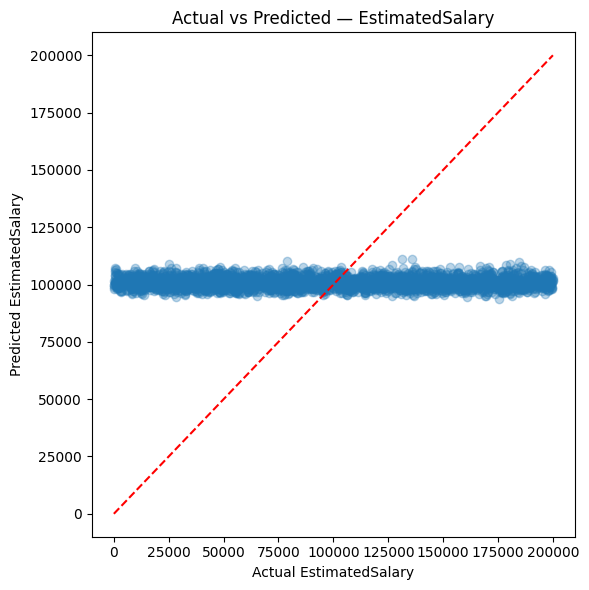

In [11]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual EstimatedSalary')
plt.ylabel('Predicted EstimatedSalary')
plt.title('Actual vs Predicted — EstimatedSalary')
plt.tight_layout()
plt.show()

### 3.9 Interpretation

**R² ≈ 0** means the model explains essentially none of the variance in
`EstimatedSalary` — predictions cluster near the average salary regardless of the
input features, and the scatter plot above will look like a shapeless cloud rather
than a diagonal line. This isn't a coding mistake or a bad model choice — in this
dataset, `EstimatedSalary` was generated independently of the other columns, so no
model (linear or otherwise) could predict it meaningfully from this data. Knowing
*when a model genuinely can't work* is just as important as building one that does.

## 4. Predicting `Balance`

Same process as above, just swapping the target. This time we drop `Balance` from `X`
instead of `EstimatedSalary`, and put `EstimatedSalary` back in as a feature.

In [12]:
X = df1.drop(columns=['CustomerId', 'Surname', 'Balance'])
y = df1['Balance']

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

Rebuild the preprocessing step with the updated feature list (`EstimatedSalary` is now
a numeric input feature instead of the target).

In [14]:
num_features = ["CreditScore", "Age", "EstimatedSalary", "NumOfProducts", "Tenure"]
cat_features = ["Geography", "Gender", "HasCrCard", "IsActiveMember", "Exited"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(drop="first"), cat_features)
    ]
)

In [15]:
pipe = Pipeline([
    ("preprocess", preprocessor),
    ("linear_regression", LinearRegression())
])
pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('linear_regression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['CreditScore','Geography','Gender',...,'IsActiveMember','EstimatedSalary', 'Exited']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through

In [16]:
y_pred = pipe.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f'MAE  : {mae:.2f}')
print(f'RMSE : {rmse:.2f}')
print(f'R2   : {r2:.4f}')

MAE  : 46231.59
RMSE : 53388.46
R2   : 0.2611


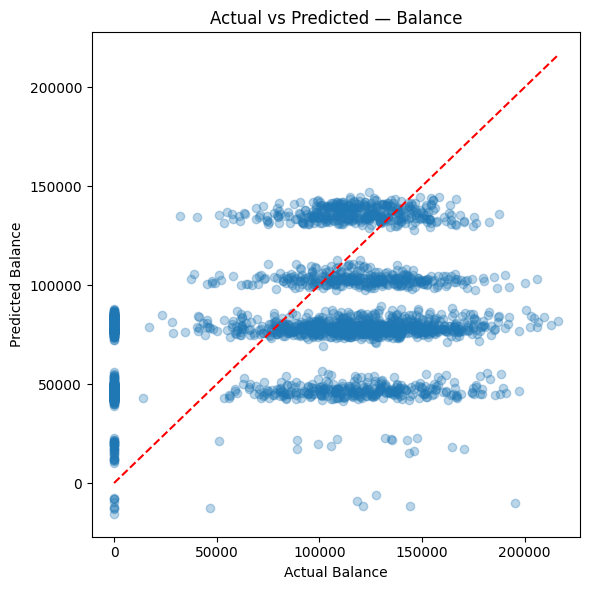

In [17]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Balance')
plt.ylabel('Predicted Balance')
plt.title('Actual vs Predicted — Balance')
plt.tight_layout()
plt.show()

### Interpretation

**R² ≈ 0.26** — noticeably better than the salary model, though still far from strong.
This means the model captures some real structure: recall from the outlier-checking
notebook that `Balance` has a bimodal pattern (a cluster at exactly €0, and a cluster
around €100k–150k). Features like `Geography` and `NumOfProducts` correlate with which
cluster a customer falls into, which is where this partial predictive power comes from.
It's a genuine, if modest, signal — not noise.

## 5. Predicting `CreditScore`

Same process again, this time predicting `CreditScore` from everything else, including
both `EstimatedSalary` and `Balance` as input features.

In [18]:
X = df1.drop(columns=['CustomerId', 'Surname', 'CreditScore'])
y = df1['CreditScore']

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [20]:
num_features = ["Age", "EstimatedSalary", "Balance", "NumOfProducts", "Tenure"]
cat_features = ["Geography", "Gender", "HasCrCard", "IsActiveMember", "Exited"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(drop="first"), cat_features)
    ]
)

In [21]:
pipe = Pipeline([
    ("preprocess", preprocessor),
    ("linear_regression", LinearRegression())
])
pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('linear_regression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['Geography','Gender','Age',...,'IsActiveMember','EstimatedSalary', 'Exited']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This s

In [22]:
y_pred = pipe.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f'MAE  : {mae:.2f}')
print(f'RMSE : {rmse:.2f}')
print(f'R2   : {r2:.4f}')

MAE  : 79.33
RMSE : 97.73
R2   : -0.0043


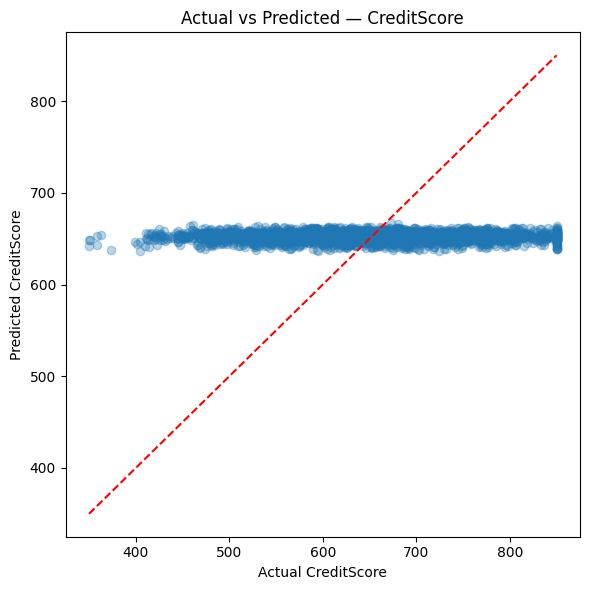

In [23]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual CreditScore')
plt.ylabel('Predicted CreditScore')
plt.title('Actual vs Predicted — CreditScore')
plt.tight_layout()
plt.show()

### Interpretation

**R² ≈ 0**, same story as `EstimatedSalary`. Like salary, `CreditScore` in this dataset
was generated independently of the other features — there's no real relationship for
a linear model (or any model) to find.

## 6. Summary

| Target | R² | Interpretation |
|---|---|---|
| EstimatedSalary | ~0.00 | Unpredictable — generated independently of other features |
| Balance | ~0.26 | Weak but real signal, tied to Geography/NumOfProducts |
| CreditScore | ~0.00 | Unpredictable — generated independently of other features |

### Why this matters for the next notebook

None of these financial variables can reliably predict each other in a straightforward
linear way. That includes the relationship between these features and `Exited`
(churn) — churn is a *yes/no* outcome, not a continuous number, so linear regression
isn't even the right tool for that question in the first place. That's exactly why the
next notebook switches to **Logistic Regression** — a model designed specifically for
predicting categories (like churned vs. not churned) rather than continuous values.